In [1]:
try:
    import lightgbm as lgb
except:
    %pip install -q -U lightgbm
    import lightgbm as lgb

lgb.__version__

'4.6.0'

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, RocCurveDisplay
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder, LabelBinarizer, label_binarize

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RED':    '\033[35m',
    'RESET':  '\033[0m',
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [6]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [7]:
train.describe() 

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,690088.000000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,1.025969,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,0.375035,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,0.000000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,1.000000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,1.000000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,1.000000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,2.000000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


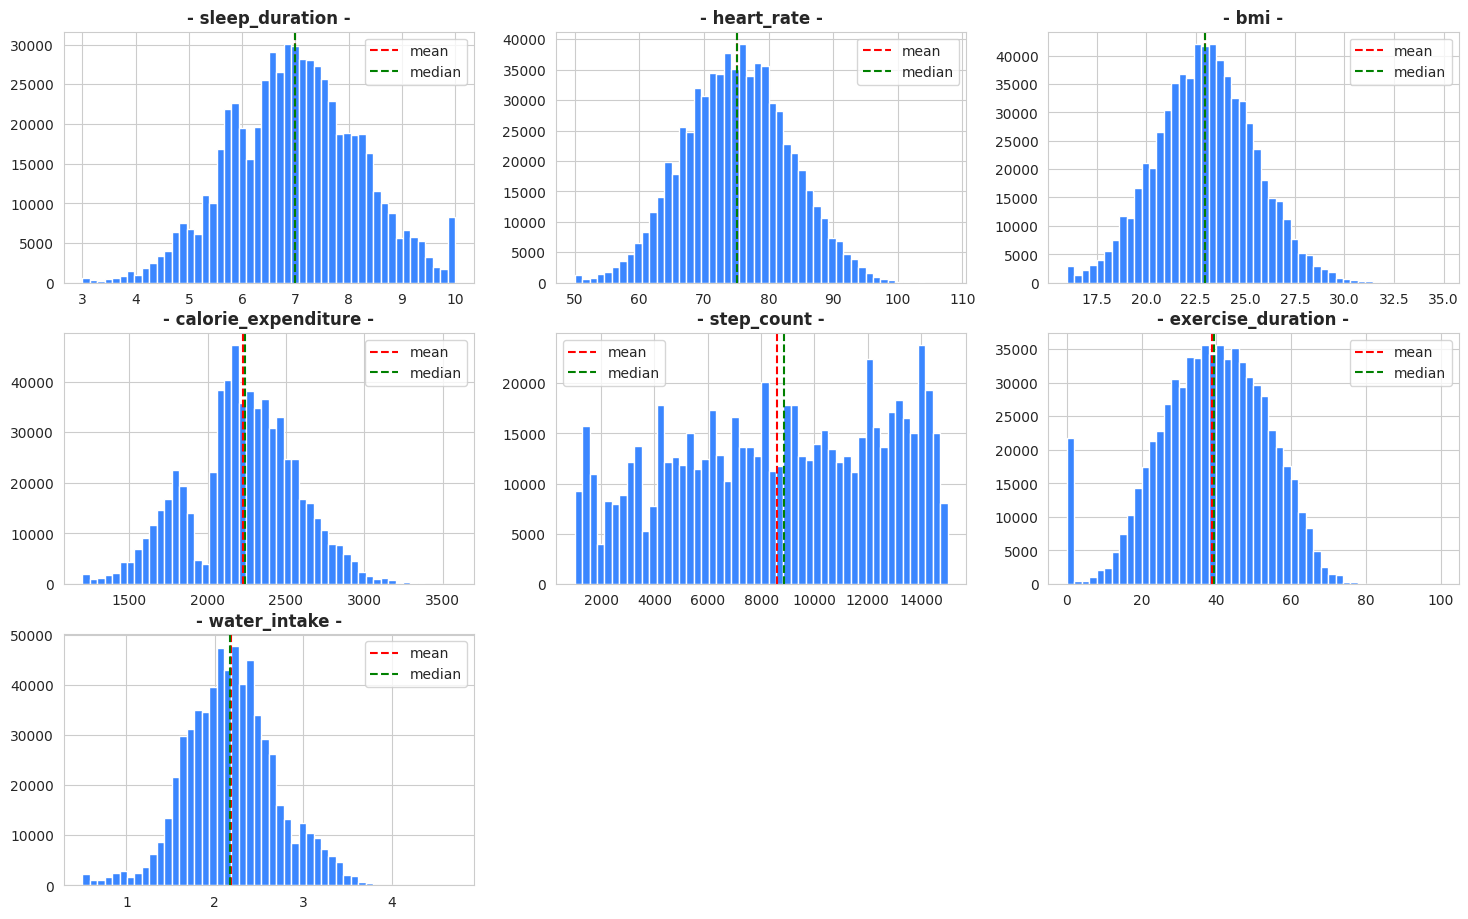

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()
    
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


## FEATURE ENGINEERING

In [10]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    weights_ = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return weights_

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [11]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories):
    for c in categories:
        X[c] = X[c].factorize()[0]
        X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

    ## -- Train Model --
    print('Training base model... ', end='')
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        sample_weight=get_sample_weights(y_train, y_train)
    )

    model_importances = pd.Series(model.feature_importances_, index=X.columns)
    preds = model.predict_proba(X_test)
    score = balanced_acc(y_test, preds)
    print('Complete!', end='')
    print(f" • Balanced_Accuracy: {score:.5f}")

    ## -- Compute Permutation Importances --
    print('Training permutation... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=5, # max_samples=0.8,
        sample_weight=get_sample_weights(y_test, y_test),
        scoring='balanced_accuracy',
        random_state=0, n_jobs=-1,
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(16, 0.35*len(X.columns)))
    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")

    axs[1].boxplot(
        result.importances[perm_sorted_idx].T,
        orientation='horizontal',
        tick_labels=X.columns[perm_sorted_idx],
        whis=(0, 100),
    )
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion Importance")

    _s_t = 'Model vs. Permutation on validation data'
    fig.suptitle(_s_t, y=1.00, fontweight='bold')
    _ = fig.tight_layout()

    df = pd.Series(dict(zip(
        X.columns[perm_sorted_idx],
        result.importances_mean[perm_sorted_idx].ravel()
    )))

    return df.nlargest(50, keep='all').to_frame('Importance Score')

print('Permutaion function script ready!')

Permutaion function script ready!


In [12]:
# %%time

# _model = lgb.LGBMClassifier(**{
#     'objective': 'multiclass', # multiclass_ova
#     'metric': 'multiclass',
#     'num_classes': 3,
#     # 'class_weight': 'balanced',
#     'importace_type': 'gain',
#     'verbose': -1,
#     'nthreads': -1,
#     'random_state': CFG['SEED'],
#     'device': 'gpu' if torch.cuda.is_available() else 'cpu',
# })

# top_features_df = plot_permutation_importance(
#     _model,
#     train.drop(columns=[TARGET]),
#     train[TARGET],
#     CATS,
# )

# top_features_df

In [13]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_valid = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train.loc[:, new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_valid.loc[:, new_col] = opt_multi_b.transform(x_valid[col].to_numpy(), metric=metric)
#         x_test.loc[:, new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

# print('Binning function ready')

In [14]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='cp', # 'cp', 'mip', 'lr'
#     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100, 
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [15]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Optimal Binned Features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [16]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [17]:
# BIN_TABLES[0].analysis()

In [18]:
ROUNDS = []
FLOORS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [19]:
# for col in ['bmi']:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 2):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     # if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #     #     DROP_COLS.append(r_n)
#     #     # else:
#     #     ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(-3, 7):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     print(f"\nEqual binning... ", end='')
#     for b in [[-np.inf, 19, 25, 30, np.inf]]: # 100, 500, 1000
#         b_n = f'{col}_bin_'
#         print(b_n+', ', end='')
#         train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#         test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         E_BINS.append(b_n)

#     # print(f"\nQuantile binning... ", end='')
#     # for q in [32, 64, 128]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [20]:
# for col in ['water_intake', 'exercise_duration', 'step_count']:
#     print(f"\nRounding... ", end='')
#     for r in range(-3, 2):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         # if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#         #     DROP_COLS.append(r_n)
#         # else:
#         ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(-3, 7):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nQuantile binning... ", end='')
#     # for q in [32, 64, 128]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [21]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

train[ROUNDS+FLOORS+DIGITS+E_BINS+Q_BINS].nunique()

Features dropped: []


Series([], dtype: float64)

In [22]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [23]:
# ## -- Arithmetic interaction --
# print("Creating arithemtic features...", end='')
# for df in tqdm([train, test, orig]):
#     df['_bmi_gt_30'] = (df['bmi'] > 30).astype(int).astype('category')
#     df['_sleep_lt_30'] = (df['sleep_duration'] < 6).astype(int).astype('category')

# #     df['g_i_sub_'] = df['g'] - df['i']
# #     df['r_z_sub_'] = df['r'] - df['z']

# #     df['i_z_sub_'] = df['i'] - df['z']
# #     df['r_i_sub_'] = df['r'] - df['i']
# #     df['u_z_sub_'] = df['u'] - df['z']
    
# #     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

# #     for band in ['g', 'i']:
# #         b_col = f"_div_{band}_redshift"
# #         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# arith_cols = [c for c in train.columns if c.startswith('_')]
# # color_bands.append('stellar_locus_dist')

# train[arith_cols]

In [24]:
# ## -- Cyclic encoding --

# for df in tqdm([train, test, orig], desc="Cyclical features"):
#     for col in ['alpha', 'delta']:
#         for p in [180, 360]:
#             df[f"{col}_sin_{p}"] = np.sin(2 * np.pi * df[col] / p).astype('float32')
#             df[f"{col}_cos_{p}"] = np.cos(2 * np.pi * df[col] / p).astype('float32')

In [25]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [26]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(NUMS, 3)), desc='Triplewise'):
# #     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, red_rounds)), desc='One-to-Many'):
# #     n_col = f"_Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total interaction features: {len(INTER)}")

# train[INTER].head()

In [27]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        cat_cols = cat_cols
        mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if cat_cols is None:
            cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        mappings_ = {}
        for col in cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [29]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_valid_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_valid_df   = X_valid_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_valid_df   = fill_conditionally(X_valid_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_valid_df, X_test_df, ORIG

In [30]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Total original features: {len(ORIG_COLS)}")

In [31]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in BASE:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [32]:
# %%time

# _model = lgb.LGBMClassifier(**{
#     'objective': 'multiclass', # multiclass_ova
#     'metric': 'multiclass',
#     'num_classes': 3,
#     # 'class_weight': 'balanced',
#     'importace_type': 'gain',
#     'verbose': -1,
#     'nthreads': -1,
#     'random_state': CFG['SEED'],
#     'device': 'gpu' if torch.cuda.is_available() else 'cpu',
# })

# top_features_df = plot_permutation_importance(
#     _model,
#     train.drop(columns=[TARGET]),
#     train[TARGET],
#     CATS,
# )

# top_features_df

In [33]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c], orig[c]])
    # combine  = combine.factorize()[0]
    combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[len(train)+len(test):]

print('Label encoding complete!')

Label encoding complete!


In [34]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 13


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


# ML TRAINING

In [35]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

print()

!pip show venn_abers

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.

Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [36]:
# def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold,
#                cat_cols=None, use_weights=False, calibrate=False,
#                early_stop=100, print_every=100):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     X = train_df[features]
#     y = train_df[target]

#     num_cls = y.nunique()

#     oof_preds = np.zeros((len(X), num_cls))
#     test_preds = np.zeros((len(test_df), num_cls))
    
#     fold_scores = []
#     brier_scores = []
#     feat_importances = []

#     for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#         print(f"\n##### FOLD {idx}/{kfold.n_splits} | Calibration: {str(calibrate)} #####")

#         ## -- Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df[features].copy()

#         # ## -- OPTION A: Concatenate original data --
#         # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

#         # ## -- OPTION B: TE Merge original data --
#         # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
#         #     orig,
#         #     X_train,
#         #     X_valid,
#         #     X_test,
#         #     features=BASE,
#         #     target=TARGET,
#         #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#         #     # fill_nan=True,
#         # )

#         # CE_COLS = cats+ROUNDS
#         # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
#         # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
#         # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
#         # X_valid   = cm_enc.transform(X_valid).fillna(-1)
#         # X_test  = cm_enc.transform(X_test).fillna(-1)

#         # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
#         #     x_tr=X_train,
#         #     y_tr=y_train,
#         #     x_vl=X_valid,
#         #     x_ts=X_test,
#         #     bin_features=NUMS,
#         #     solver='cp', # 'cp', 'mip', 'lr'
#         #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#         #     pre_bins=100, 
#         #     # period=300,
#         # )

#         # combined = pd.concat([X_train, X_valid, X_test])
#         # for c in cat_cols:
#         #     combined[c] = combined[c].astype(str).astype('category')

#         # X_train = combined[:len(X_train)]
#         # X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
#         # X_test  = combined[len(X_train)+len(X_valid):]

#         # ## -- Target Encoding -- 
#         # te_cols = ROUNDS
#         # print(f" • Target Encoding {len(te_cols)} features... ")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

#         # te_cols = INTER
#         # print(f" • Target Encoding {len(te_cols)} features... ")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

#         # lb = LabelBinarizer()
#         # y_val_one_hot = lb.fit_transform(y_valid)

#         callbacks = [lgb.early_stopping(early_stop), lgb.log_evaluation(print_every),
#             # lgb.record_evaluation(eval_result),
#         ]

#         if calibrate:
#             print(f" • Training base model {X_train.shape}... ")
#             model = lgb.LGBMClassifier(**params)
#             model.fit(
#                 X_train, y_train,
#                 # eval_X=X_valid, eval_y=y_valid,
#                 eval_set=[(X_train, y_train), (X_valid, y_valid)],
#                 eval_names=['train', 'valid'],
#                 sample_weight=get_sample_weights(y_base, y_train) if use_weights else None,
#                 # eval_class_weight=get_class_weights(y_train, y_train),
#                 callbacks=callbacks,
#             )
            
#             feat_importances.append(model.feature_importances_.ravel())
            
#             base_acc   = balanced_acc(y_valid, model.predict_proba(X_valid))
#             base_brier = multi_class_brier(y_valid, model.predict_proba(X_valid), [*mapping.values()])

#             ## -- Calibrate outputs --
#             print(f" • Calibrating (venn-abers) {X_calib.shape}... ")
#             vao = VennAbersCalibrator() # - Get OOF predictions -
#             venn_oof_preds = vao.predict_proba(
#                 p_cal   = model.predict_proba(X_calib),
#                 y_cal   = y_calib.to_numpy(),
#                 p_test  = model.predict_proba(X_valid),
#                 va_type = 'one_vs_all',
#             )
#             oof_preds[val_idx] = venn_oof_preds

#             vat = VennAbersCalibrator() # - Get TEST predictions -
#             venn_test_preds = vat.predict_proba(
#                 p_cal   = model.predict_proba(X_calib),
#                 y_cal   = y_calib.to_numpy(),
#                 p_test  = model.predict_proba(X_test),
#                 va_type = 'one_vs_all',
#             )

#             test_preds += venn_test_preds

#             ## -- Fold scores --
#             fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], [*mapping.values()])
#             fold_scores.append(fold_score); brier_scores.append(brier_score)
            
#             print(f"{CFG['YELLOW']}Fold {idx}")
#             print(f"base_acc:  {base_acc:.5f} | base_brier:  {base_brier:.5f}")
#             print(f"calib_acc: {fold_score:.5f} | calib_brier: {brier_score:.5f}")
#             print(f"{CFG['RESET']}")
#         ## ====================================================================================
#         else:
#             print(f"Training {model_name} model {X_train.shape}... ")
#             model = lgb.LGBMClassifier(**params)
#             model.fit(
#                 X_train, y_train,
#                 # eval_X=X_valid, eval_y=y_valid,
#                 eval_set=[(X_train, y_train), (X_valid, y_valid)],
#                 eval_names=['train', 'valid'],
#                 sample_weight=get_sample_weights(y_train, y_train) if use_weights else None,
#                 # eval_class_weight=get_class_weights(y_train, y_train),
#                 callbacks=callbacks,
#             )

#             feat_importances.append(model.feature_importances_.ravel())

#             ## -- Predict on val and test sets --
#             oof_preds[val_idx] = model.predict_proba(X_valid)
#             test_preds += model.predict_proba(X_test)
    
#             ## -- Calculate and print fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], [*mapping.values()])
#             fold_scores.append(fold_score); brier_scores.append(brier_score)

#             print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         ## ------------------------------------------------------------------------------------

#     ## -- Average test predictions --
#     test_preds /= kfold.n_splits

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{kfold.n_splits}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#         print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(balanced_acc(y, oof_preds), 5)
#     oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f"OOF brier: {oof_brier}")
#     print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins\n')

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'scores': oof_score,
#         'models': model,
#         'importances': feat_importances,
#         'val_data': [X_valid, y_valid],
#     }

# print("⚙️ Training function ready ⚙️")

In [37]:
## -- MULTI-SEED --
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold,
               cat_cols=None, use_weights=False, calibrate=False,
               multi_seeds=[42, 111, 0], early_stop=100, print_every=100):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    X = train_df[features]
    y = train_df[target]

    num_cls = y.nunique()

    oof_preds = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))
    
    fold_scores = []
    brier_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\nFOLD {idx}/{kfold.n_splits} | {get_system_info()} | Calibrate: {str(calibrate)}")

        ## -- Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        oof_seeds  = np.zeros((len(X_valid), num_cls))
        test_seeds = np.zeros((len(X_test), num_cls))

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        callbacks = [
            # lgb.early_stopping(early_stop),
            lgb.log_evaluation(print_every),
            # lgb.record_evaluation(eval_result),
        ]

        if calibrate:
            print(f" • Training base model {X_train.shape}... ")
            model = lgb.LGBMClassifier(**params)
            model.fit(
                X_train, y_train,
                # eval_X=X_valid, eval_y=y_valid,
                eval_set=[(X_train, y_train), (X_valid, y_valid)],
                eval_names=['train', 'valid'],
                sample_weight=get_sample_weights(y_base, y_train) if use_weights else None,
                # eval_class_weight=get_class_weights(y_train, y_train),
                callbacks=callbacks,
            )
            
            feat_importances.append(model.feature_importances_.ravel())
            
            base_acc   = balanced_acc(y_valid, model.predict_proba(X_valid))
            base_brier = multi_class_brier(y_valid, model.predict_proba(X_valid), [*mapping.values()])

            ## -- Calibrate outputs --
            print(f" • Calibrating (venn-abers) {X_calib.shape}... ")
            vao = VennAbersCalibrator() # - Get OOF predictions -
            venn_oof_preds = vao.predict_proba(
                p_cal   = model.predict_proba(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict_proba(X_valid),
                va_type = 'one_vs_all',
            )
            oof_preds[val_idx] = venn_oof_preds

            vat = VennAbersCalibrator() # - Get TEST predictions -
            venn_test_preds = vat.predict_proba(
                p_cal   = model.predict_proba(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict_proba(X_test),
                va_type = 'one_vs_all',
            )

            test_preds += venn_test_preds

            ## -- Fold scores --
            fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], [*mapping.values()])
            fold_scores.append(fold_score); brier_scores.append(brier_score)
            
            print(f"{CFG['YELLOW']}Fold {idx}")
            print(f"base_acc:  {base_acc:.5f} | base_brier:  {base_brier:.5f}")
            print(f"calib_acc: {fold_score:.5f} | calib_brier: {brier_score:.5f}")
            print(f"{CFG['RESET']}")
        ## ====================================================================================
        else:
            for i, seed in tqdm(enumerate(multi_seeds), total=len(multi_seeds), desc="Training seeds"):
                print(f"Training with seed -> {seed}")
                params['random_state'] = seed

                ## -- Shuffle X_train --
                full_train = pd.concat([X_train, y_train], axis=1)
                shuffled_full_train = full_train.sample(frac=1.0, random_state=seed)
                X_train_1 = shuffled_full_train.iloc[:, :-1].copy()
                y_train_1 = shuffled_full_train.iloc[:, -1].copy()
                ## -----------------------------------------------------------------------------
                print(f"Training {model_name} model {X_train_1.shape}... ")
                model = lgb.LGBMClassifier(**params)
                model.fit(
                    X_train_1, y_train_1,
                    # eval_X=X_valid, eval_y=y_valid,
                    eval_set=[(X_train, y_train), (X_valid, y_valid)],
                    eval_names=['train', 'valid'],
                    sample_weight=get_sample_weights(y_train, y_train) if use_weights else None,
                    # eval_class_weight=get_class_weights(y_train, y_train),
                    callbacks=callbacks,
                )
                oof_seeds  += model.predict_proba(X_valid)
                test_seeds += model.predict_proba(X_test)
                print(f"\tSeed ({seed}) score: {balanced_acc(y_valid, model.predict_proba(X_valid)):.5f}")

            feat_importances.append(model.feature_importances_.ravel())

            ## -- Predict on val and test sets --
            oof_preds[val_idx] = oof_seeds / len(multi_seeds)
            test_preds += test_seeds / len(multi_seeds)

            ## -- Calculate and print fold score --
            fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

            fold_scores.append(fold_score)
            brier_scores.append(brier_score)

            print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
            # ----------------------------------------------------------------------------------------

    ## -- Average test predictions --
    test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'scores': oof_score,
        'models': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [38]:
all_predictions = {}

ALL_CATS = CATS
MULTI_SEEDS = [42, 777, 1234, 24611, 0]

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])
skf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [39]:
# plt.figure(figsize=(18, 12))
# sns.heatmap(train[ROUNDS].corr(), annot=True, fmt='.2f', cbar=False)
# plt.tight_layout()
# plt.show()

In [40]:
USE_FULL_TRAIN = True
USE_CALIBATOR  = False

x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


## TEST TRAINER

In [41]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_predictions:
#     all_predictions.clear()

# tri_ = '_' # VERS

# OUTER_ = [0]
# INNER_ = [0]
# p_name   = ['l1', 'l2']

# for i, outer in enumerate(OUTER_):
#     for j, inner in enumerate(INNER_):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUTER_)} of {p_name[1]} {j+1}/{len(INNER_)} <<<")
#         PARAMS = {
#             # 'boosting': 'dart',
#             # ---------------------------------
#             'data_sample_strategy': 'goss',
#             'top_rate': 0.6,
#             'other_rate': 0.2,
#             # ---------------------------------
#             'objective': 'multiclass', 
#             'metric': 'multiclass',
#             'num_classes': NUM_CLASSES,
#             # 'class_weight': 'balanced',
#             # 'max_leaves': 31,
#             # 'n_estimators': 100,
#             'learning_rate': 0.08,
#             # 'max_depth': outer,
#             # 'bagging_fraction': outer, # disable for 'goss'
#             'feature_fraction': 0.6,
#             # # 'feature_fraction_bynode': outer, # disable for 'goss'
#             # # 'bagging_freq': outer,         # disable for 'goss'
#             'max_bins': 1000,
#             # 'reg_alpha': outer,
#             # 'reg_lambda': inner,
#             'min_data_in_leaf': 180,
#             # 'max_cat_to_onehot': 9,
#             'importance_type': 'gain',
#             'random_state': CFG['SEED'],
#             'verbosity': -1,
#             'n_jobs': -1,
#             'device': 'gpu' if torch.cuda.is_available() else 'cpu',
#         }
    
#         n = tri_ + f"{p_name[0]}={OUTER_[i]}__{p_name[1]}={INNER_[j]}"
#         all_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train_data,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kfold=skf,
#             cat_cols=ALL_CATS,
#             use_weights=True,
#             calibrate=USE_CALIBATOR,
#             early_stop=100,
#             print_every=100, 
#         )

# print(f"\n===== ☑️ Training complete! {len(all_predictions)} model(s) =====\n")

In [42]:
# 5-FOLD CV: bagging
# ==================================================
# n_est=200, leaves=31, sub=0.8, col=0.6, lr=0.09, sub=0.8, col=0.6, bins=600, leaf=80, l1=0, l2=0
# ==================================================
#  • Fold 1 score: 0.94976 | brier: 0.09367
#  • Fold 2 score: 0.95065 | brier: 0.09324
#  • Fold 3 score: 0.94912 | brier: 0.09131
#  • Fold 4 score: 0.95122 | brier: 0.09040
#  • Fold 5 score: 0.94824 | brier: 0.09188
# -------------------------------------------------|
# OOF score: 0.9498
# AVG score: 0.94980 ± 0.00106
# -------------------------------------------------|
# OOF brier: 0.0921
# AVG brier: 0.09210 ± 0.00121
# -------------------------------------------------|
# 0.66 mins


# 5-FOLD CV: goss
# ==================================================
# n_est=100, leaves=31, top_r=0.6, other=0.2, col=0.6, lr=0.08, bins=1000, leaf=180, l1=0, l2=0
# ==================================================
#  • Fold 1 score: 0.94968 | brier: 0.09451
#  • Fold 2 score: 0.95070 | brier: 0.09428
#  • Fold 3 score: 0.94948 | brier: 0.09246
#  • Fold 4 score: 0.95139 | brier: 0.09136
#  • Fold 5 score: 0.94795 | brier: 0.09302
# -------------------------------------------------|
# OOF score: 0.94984
# AVG score: 0.94984 ± 0.00117
# -------------------------------------------------|
# OOF brier: 0.09313
# AVG brier: 0.09313 ± 0.00117
# -------------------------------------------------|
# 0.77 mins

In [43]:
# all_scores = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == 'scores':
#             all_scores[k] = y

# plt.figure(figsize=(16, 6))
# ax1 = sns.lineplot([*all_scores.values()], marker='s')

# y_add = 1e-5

# for i, s1 in enumerate([*all_scores.values()]):
#     ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

# # plt.ylim((0.94, 0.955))
# plt.legend(loc='best')
# plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=90)
# plt.title('XGB model', fontdict={'weight': 'semibold', 'size': 15})

# plt.tight_layout() 
# plt.show()

In [44]:
# all_feat_importances = {}
# all_val_data = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == 'importances':
#             all_feat_importances[k] = np.mean(y, axis=0)
#         elif x == 'val_data':
#             all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

# top_n = 25

# for i, (m, fi) in enumerate(all_feat_importances.items()):
#     fi_df = pd.DataFrame({
#         'feature': all_val_data[m][0].columns,
#         'importance': fi,
#     }).sort_values(by='importance', ascending=False).reset_index(drop=True)
    
#     plt.figure(figsize=(15, len(all_feat_importances)*5))
#     plt.subplot(len(all_feat_importances), 1, i+1)
#     sns.barplot(data=fi_df.head(top_n), x='importance', y='feature')
#     plt.title(f"{m}: Avg. {CFG['FOLDS']}-Fold Feature Importances", fontweight='semibold')

#     plt.tight_layout() 
#     plt.show()

#     print()

## MAIN TRAINER

In [45]:
## ==================== BOOST
# n_est=100, leaves=31, lr=0.09, sub=0.8, col=0.6, bins=600, leaf=80

bag_params = {
    # 'boosting': 'dart',
    # ----------------------------
    'objective': 'multiclass',
    'metric': 'multiclass',
    'class_weight': "balanced",
    'num_classes': NUM_CLASSES,
    'n_estimators': 200,
    'max_leaves': 31,
    'learning_rate': 0.08,
    # 'max_depth': 6,
    'bagging_fraction': 0.8,
    'feature_fraction': 0.6,
    # 'feature_fraction_bynode': 0.8,
    # 'bagging_freq': 7,
    'max_bins': 600,
    'min_data_in_leaf': 50,
    # 'reg_alpha': 0,
    # 'reg_lambda': 0,
    # 'max_cat_to_onehot': 9,
    'importace_type': 'gain',
    'random_state': CFG['SEED'],
    'verbosity': -1,
    'n_jobs': -1,
    # 'device': 'gpu' if torch.cuda.is_available() else 'cpu',
}

n = f"lgb_bag_calib" if USE_CALIBATOR else f"lgb_bag"

# for value in [12, 15]:
#     bag_params['max_depth'] = value
#     n = f"lgb_bag_" + str(value)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bag_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_weights=False,
    multi_seeds=MULTI_SEEDS,
    calibrate=USE_CALIBATOR,
    early_stop=100,
    print_every=100, 
)


===== Starting CV: lgb_bag =====

FOLD 1/5 | CPU: 4 | Calibrate: False


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.186309	valid's multi_logloss: 0.189662
[200]	train's multi_logloss: 0.172937	valid's multi_logloss: 0.180994
	Seed (42) score: 0.95069
Training with seed -> 777
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.187134	valid's multi_logloss: 0.190557
[200]	train's multi_logloss: 0.173663	valid's multi_logloss: 0.181816
	Seed (777) score: 0.95078
Training with seed -> 1234
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.186661	valid's multi_logloss: 0.190136
[200]	train's multi_logloss: 0.173264	valid's multi_logloss: 0.181414
	Seed (1234) score: 0.95045
Training with seed -> 24611
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.185946	valid's multi_logloss: 0.189459
[200]	train's multi_logloss: 0.172747	valid's multi_logloss: 0.181029
	Seed (24611) score: 0.95072
Training with seed -> 0
Training lgb_bag model (552070, 13)... 


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.186822	valid's multi_logloss: 0.190568
[200]	train's multi_logloss: 0.173603	valid's multi_logloss: 0.182161
	Seed (42) score: 0.95133
Training with seed -> 777
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.18708	valid's multi_logloss: 0.190914
[200]	train's multi_logloss: 0.174077	valid's multi_logloss: 0.182716
	Seed (777) score: 0.95177
Training with seed -> 1234
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.187004	valid's multi_logloss: 0.190852
[200]	train's multi_logloss: 0.173553	valid's multi_logloss: 0.181803
	Seed (1234) score: 0.95132
Training with seed -> 24611
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.186603	valid's multi_logloss: 0.190319
[200]	train's multi_logloss: 0.173277	valid's multi_logloss: 0.18154
	Seed (24611) score: 0.95149
Training with seed -> 0
Training lgb_bag model (552070, 13)... 
[1

...

Training with seed -> 42
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.185871	valid's multi_logloss: 0.193192
[200]	train's multi_logloss: 0.172608	valid's multi_logloss: 0.184653
	Seed (42) score: 0.94907
Training with seed -> 777
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.186072	valid's multi_logloss: 0.193269
[200]	train's multi_logloss: 0.172958	valid's multi_logloss: 0.185023
	Seed (777) score: 0.94906
Training with seed -> 1234
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.18556	valid's multi_logloss: 0.192833
[200]	train's multi_logloss: 0.171875	valid's multi_logloss: 0.183985
	Seed (1234) score: 0.94909
Training with seed -> 24611
Training lgb_bag model (552070, 13)... 
[100]	train's multi_logloss: 0.184985	valid's multi_logloss: 0.192345
[200]	train's multi_logloss: 0.172119	valid's multi_logloss: 0.184272
	Seed (24611) score: 0.94924
Training with seed -> 0
Training lgb_bag model (552070, 13)... 
[

Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Training lgb_bag model (552071, 13)... 
[100]	train's multi_logloss: 0.186747	valid's multi_logloss: 0.189283
[200]	train's multi_logloss: 0.173157	valid's multi_logloss: 0.180259
	Seed (42) score: 0.94933
Training with seed -> 777
Training lgb_bag model (552071, 13)... 
[100]	train's multi_logloss: 0.186973	valid's multi_logloss: 0.189706
[200]	train's multi_logloss: 0.173981	valid's multi_logloss: 0.181218
	Seed (777) score: 0.94968
Training with seed -> 1234
Training lgb_bag model (552071, 13)... 
[100]	train's multi_logloss: 0.18725	valid's multi_logloss: 0.189989
[200]	train's multi_logloss: 0.173761	valid's multi_logloss: 0.180784
	Seed (1234) score: 0.94944
Training with seed -> 24611
Training lgb_bag model (552071, 13)... 
[100]	train's multi_logloss: 0.186223	valid's multi_logloss: 0.188867
[200]	train's multi_logloss: 0.172976	valid's multi_logloss: 0.179997
	Seed (24611) score: 0.94948
Training with seed -> 0
Training lgb_bag model (552071, 13)... 
[

Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Training lgb_bag model (552071, 13)... 
[100]	train's multi_logloss: 0.185149	valid's multi_logloss: 0.189656
[200]	train's multi_logloss: 0.171804	valid's multi_logloss: 0.18104
	Seed (42) score: 0.94857
Training with seed -> 777
Training lgb_bag model (552071, 13)... 
[100]	train's multi_logloss: 0.185346	valid's multi_logloss: 0.18977
[200]	train's multi_logloss: 0.172755	valid's multi_logloss: 0.182006
	Seed (777) score: 0.94847
Training with seed -> 1234
Training lgb_bag model (552071, 13)... 
[100]	train's multi_logloss: 0.185563	valid's multi_logloss: 0.190069
[200]	train's multi_logloss: 0.171908	valid's multi_logloss: 0.18114
	Seed (1234) score: 0.94845
Training with seed -> 24611
Training lgb_bag model (552071, 13)... 
[100]	train's multi_logloss: 0.184514	valid's multi_logloss: 0.189012
[200]	train's multi_logloss: 0.171453	valid's multi_logloss: 0.18066
	Seed (24611) score: 0.94876
Training with seed -> 0
Training lgb_bag model (552071, 13)... 
[100

In [46]:
# ==================================================
# 5-FOLD CV: lgb_bag | multi_seeds
# ==================================================
#  • Fold 1 score: 0.95075 | brier: 0.09250
#  • Fold 2 score: 0.95140 | brier: 0.09280
#  • Fold 3 score: 0.94932 | brier: 0.09447
#  • Fold 4 score: 0.94967 | brier: 0.09170
#  • Fold 5 score: 0.94865 | brier: 0.09237
# -------------------------------------------------|
# OOF score: 0.94996
# AVG score: 0.94996 ± 0.00099
# -------------------------------------------------|
# OOF brier: 0.09277
# AVG brier: 0.09277 ± 0.00092
# -------------------------------------------------|
# 15.09 mins

# ==================================================
# 5-FOLD CV: lgb_bag
# ==================================================
#  • Fold 1 score: 0.95071 | brier: 0.09258
#  • Fold 2 score: 0.95145 | brier: 0.09277
#  • Fold 3 score: 0.94917 | brier: 0.09453
#  • Fold 4 score: 0.94950 | brier: 0.09174
#  • Fold 5 score: 0.94876 | brier: 0.09246
# -------------------------------------------------|
# OOF score: 0.94992
# AVG score: 0.94992 ± 0.00100
# -------------------------------------------------|
# OOF brier: 0.09281
# AVG brier: 0.09281 ± 0.00092
# -------------------------------------------------|
# 14.86 mins

In [47]:
## ==================== GOSS
# n_est=100, top_r=0.6, other=0.2, leaves=31, lr=0.08, col=0.6, bins=1000, leaf=180

goss_params = {
    # 'boosting': 'dart',
    # ---------------------------------
    'data_sample_strategy': 'goss',
    'top_rate': 0.6,
    'other_rate': 0.2,
    # ---------------------------------
    'objective': "multiclass",
    'metric': "multiclass",
    'class_weight': "balanced",
    'num_classes': NUM_CLASSES,
    'n_estimators': 100,
    'max_leaves': 31,
    'learning_rate': 0.08,
    # 'max_depth': DEPTH,
    'feature_fraction': 0.6,
    'min_data_in_leaf': 180,
    # 'max_bins': 254,
    # 'reg_alpha': 0.0,
    # 'reg_lambda': 0.0,
    # 'max_cat_to_onehot': 9,
    'importace_type': "gain",
    'random_state': CFG['SEED'],
    'verbosity': -1,
    'n_jobs': os.cpu_count(),
    'device': "gpu" if torch.cuda.is_available() else "cpu",
}

n = f"lgb_goss_calib" if USE_CALIBATOR else f"lgb_goss"

for value in [100, 200, 300]:
    goss_params['n_estimators'] = value
    n = f"lgb_goss_" + str(value)
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=goss_params,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        cat_cols=ALL_CATS,
        use_weights=False,
        multi_seeds=MULTI_SEEDS,
        calibrate=USE_CALIBATOR,
        early_stop=100,
        print_every=100, 
    )


===== Starting CV: lgb_goss_100 =====

FOLD 1/5 | CPU: 4 | Calibrate: False


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.187605	valid's multi_logloss: 0.190204
	Seed (42) score: 0.95020
Training with seed -> 777
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.188267	valid's multi_logloss: 0.191004
	Seed (777) score: 0.95032
Training with seed -> 1234
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.188132	valid's multi_logloss: 0.190703
	Seed (1234) score: 0.95016
Training with seed -> 24611
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.187375	valid's multi_logloss: 0.190101
	Seed (24611) score: 0.95038
Training with seed -> 0
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.187867	valid's multi_logloss: 0.190514
	Seed (0) score: 0.95023
Fold 1 acc: 0.95031 | brier: 0.09564

FOLD 2/5 | CPU: 4 | Calibrate: False


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.18851	valid's multi_logloss: 0.191579
	Seed (42) score: 0.95142
Training with seed -> 777
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.188287	valid's multi_logloss: 0.191475
	Seed (777) score: 0.95146
Training with seed -> 1234
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.188879	valid's multi_logloss: 0.192296
	Seed (1234) score: 0.95102
Training with seed -> 24611
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.187845	valid's multi_logloss: 0.191109
	Seed (24611) score: 0.95123
Training with seed -> 0
Training lgb_goss_100 model (552070, 13)... 
[100]	train's multi_logloss: 0.188394	valid's multi_logloss: 0.191659
	Seed (0) score: 0.95138
Fold 2 acc: 0.95130 | brier: 0.09587

FOLD 3/5 | CPU: 4 | Calibrate: False


...

Training with seed -> 42
Training lgb_goss_300 model (552070, 13)... 
[100]	train's multi_logloss: 0.187209	valid's multi_logloss: 0.193906
[200]	train's multi_logloss: 0.174596	valid's multi_logloss: 0.185823
[300]	train's multi_logloss: 0.165166	valid's multi_logloss: 0.180015
	Seed (42) score: 0.94908
Training with seed -> 777
Training lgb_goss_300 model (552070, 13)... 
[100]	train's multi_logloss: 0.187559	valid's multi_logloss: 0.19416
[200]	train's multi_logloss: 0.175574	valid's multi_logloss: 0.186709
[300]	train's multi_logloss: 0.165878	valid's multi_logloss: 0.180695
	Seed (777) score: 0.94919
Training with seed -> 1234
Training lgb_goss_300 model (552070, 13)... 
[100]	train's multi_logloss: 0.187561	valid's multi_logloss: 0.194199
[200]	train's multi_logloss: 0.174984	valid's multi_logloss: 0.186133
[300]	train's multi_logloss: 0.165409	valid's multi_logloss: 0.180227
	Seed (1234) score: 0.94909
Training with seed -> 24611
Training lgb_goss_300 model (552070, 13)... 
[100

Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Training lgb_goss_300 model (552071, 13)... 
[100]	train's multi_logloss: 0.188057	valid's multi_logloss: 0.189938
[200]	train's multi_logloss: 0.175698	valid's multi_logloss: 0.181753
[300]	train's multi_logloss: 0.166024	valid's multi_logloss: 0.175537
	Seed (42) score: 0.94914
Training with seed -> 777
Training lgb_goss_300 model (552071, 13)... 
[100]	train's multi_logloss: 0.188797	valid's multi_logloss: 0.19069
[200]	train's multi_logloss: 0.176095	valid's multi_logloss: 0.182111
[300]	train's multi_logloss: 0.166508	valid's multi_logloss: 0.176133
	Seed (777) score: 0.94901
Training with seed -> 1234
Training lgb_goss_300 model (552071, 13)... 
[100]	train's multi_logloss: 0.188971	valid's multi_logloss: 0.190834
[200]	train's multi_logloss: 0.175894	valid's multi_logloss: 0.181833
[300]	train's multi_logloss: 0.166695	valid's multi_logloss: 0.17609
	Seed (1234) score: 0.94898
Training with seed -> 24611
Training lgb_goss_300 model (552071, 13)... 
[100]

Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Training lgb_goss_300 model (552071, 13)... 
[100]	train's multi_logloss: 0.186747	valid's multi_logloss: 0.190658
[200]	train's multi_logloss: 0.174252	valid's multi_logloss: 0.182518
[300]	train's multi_logloss: 0.164999	valid's multi_logloss: 0.176904
	Seed (42) score: 0.94838
Training with seed -> 777
Training lgb_goss_300 model (552071, 13)... 
[100]	train's multi_logloss: 0.186799	valid's multi_logloss: 0.190682
[200]	train's multi_logloss: 0.174801	valid's multi_logloss: 0.183203
[300]	train's multi_logloss: 0.165456	valid's multi_logloss: 0.177589
	Seed (777) score: 0.94814
Training with seed -> 1234
Training lgb_goss_300 model (552071, 13)... 
[100]	train's multi_logloss: 0.186723	valid's multi_logloss: 0.190526
[200]	train's multi_logloss: 0.174146	valid's multi_logloss: 0.182448
[300]	train's multi_logloss: 0.165198	valid's multi_logloss: 0.177273
	Seed (1234) score: 0.94836
Training with seed -> 24611
Training lgb_goss_300 model (552071, 13)... 
[10

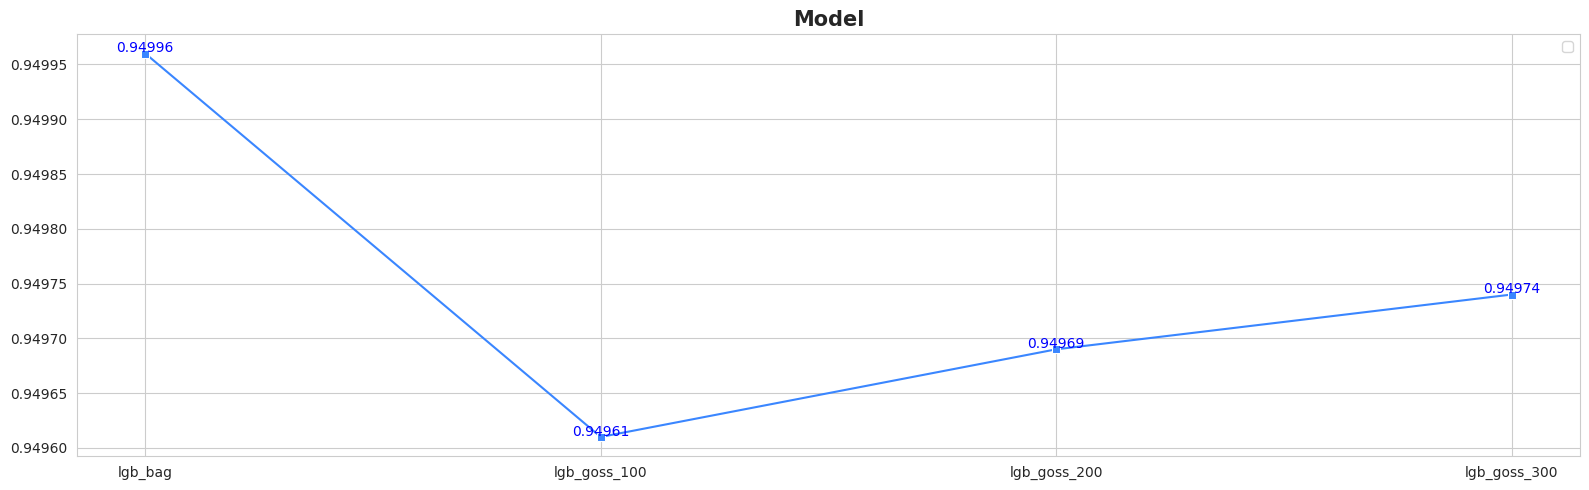

In [48]:
## -- Get Scores --
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'scores':
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot([*all_scores.values()], marker='s')

y_add = 1e-6

for i, s1 in enumerate([*all_scores.values()]):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

# plt.ylim((0.94, 0.951))
plt.legend(loc='best')
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title('Model', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout() 
plt.show()

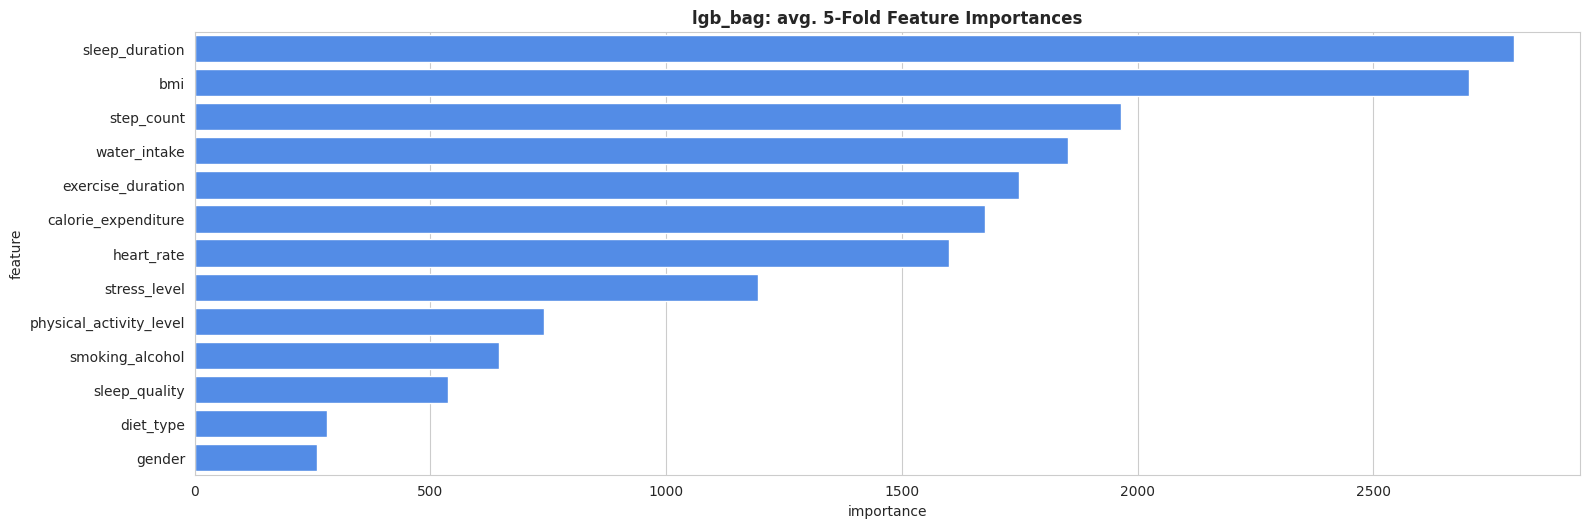

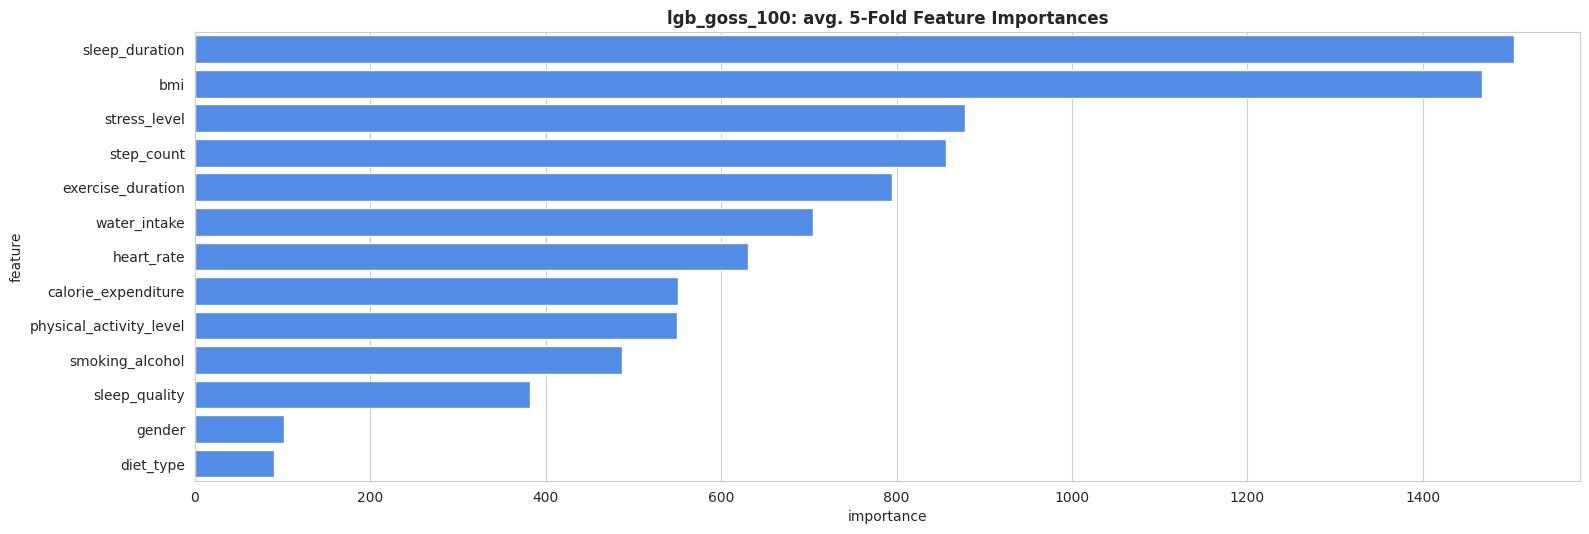

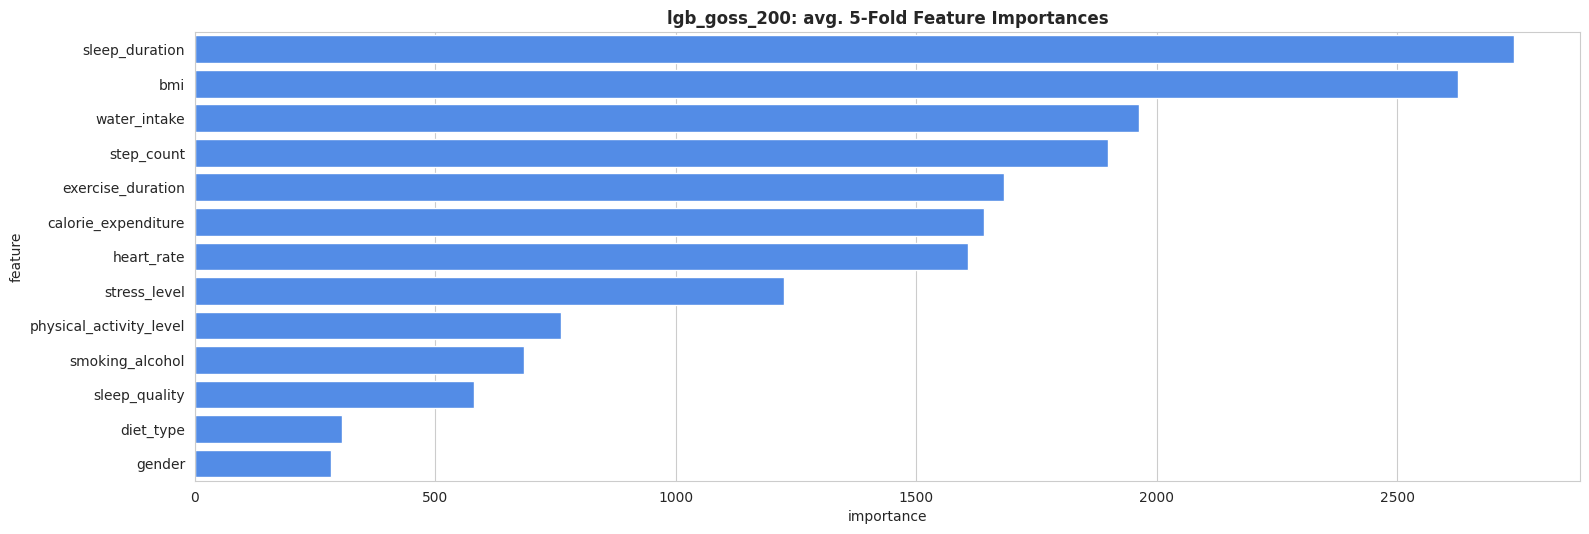

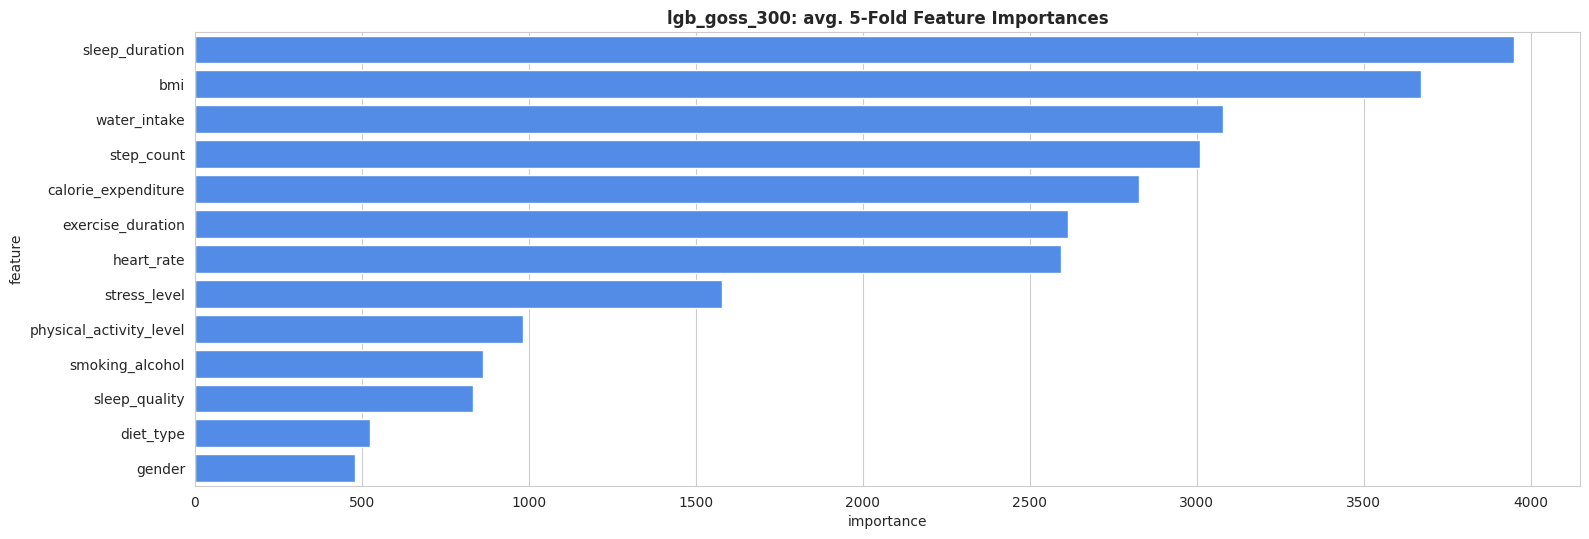

In [49]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'importances':
            all_feat_importances[k] = np.mean(y, axis=0)
        elif x == 'val_data':
            all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

top_n = 25

for i, (m, fi) in enumerate(all_feat_importances.items()):
    fi_df = pd.DataFrame({
        'feature': all_val_data[m][0].columns,
        'importance': fi,
    }).sort_values(by='importance', ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(16, len(all_feat_importances)*5))
    plt.subplot(len(all_feat_importances), 1, i+1)
    sns.barplot(data=fi_df.head(top_n), x='importance', y='feature')
    plt.title(f"{m}: avg. {CFG['FOLDS']}-Fold Feature Importances", fontweight='semibold')

    plt.tight_layout() 
    plt.show()

    print()

lgb_bag_94996 saved!


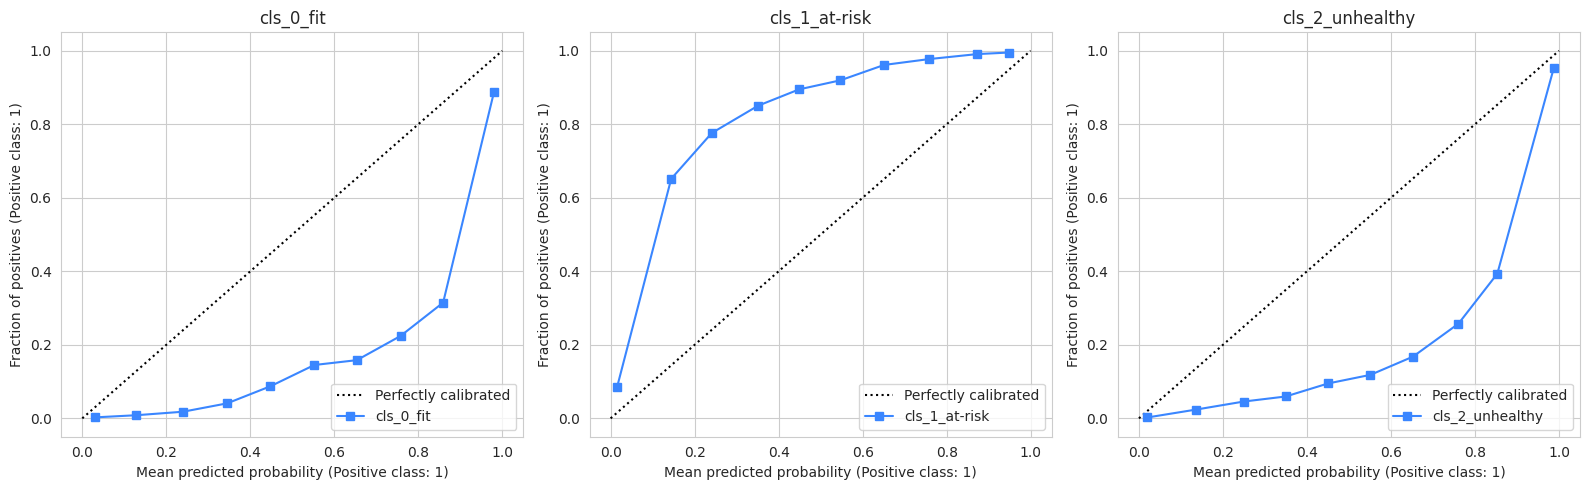

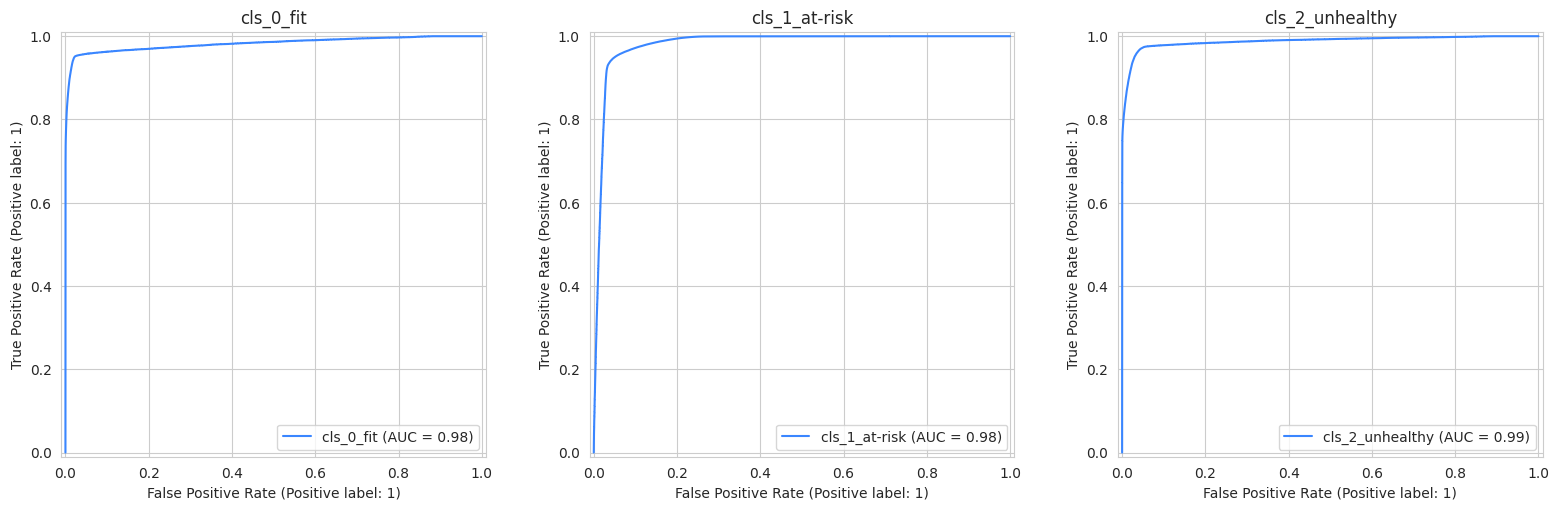


lgb_goss_100_94961 saved!


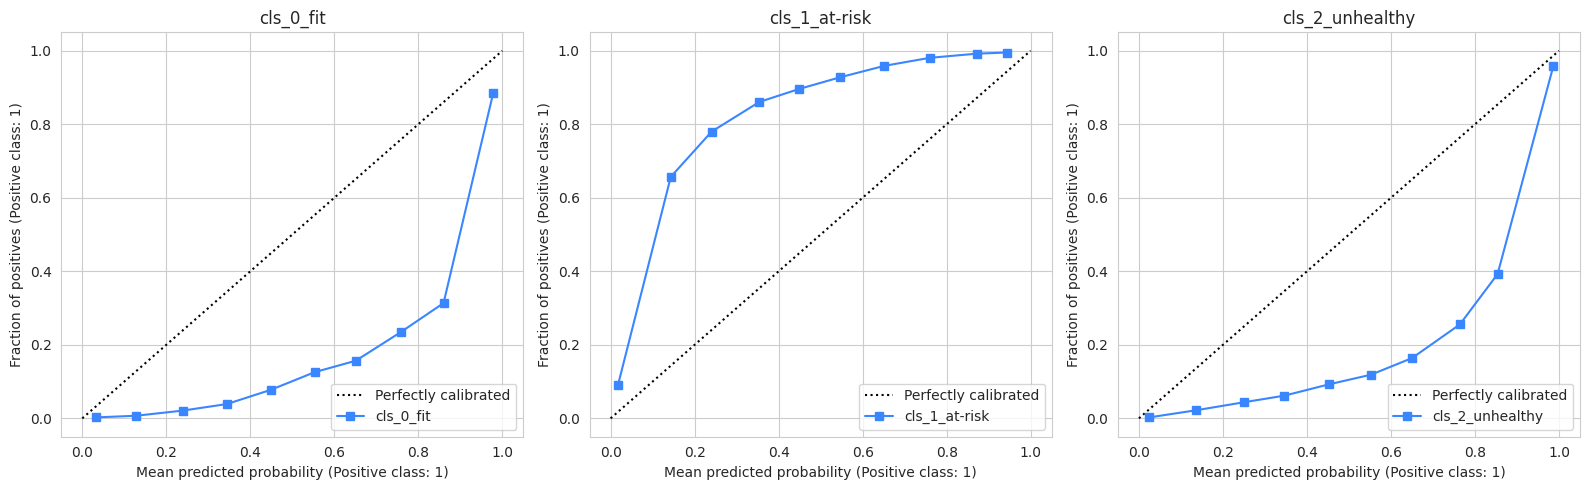

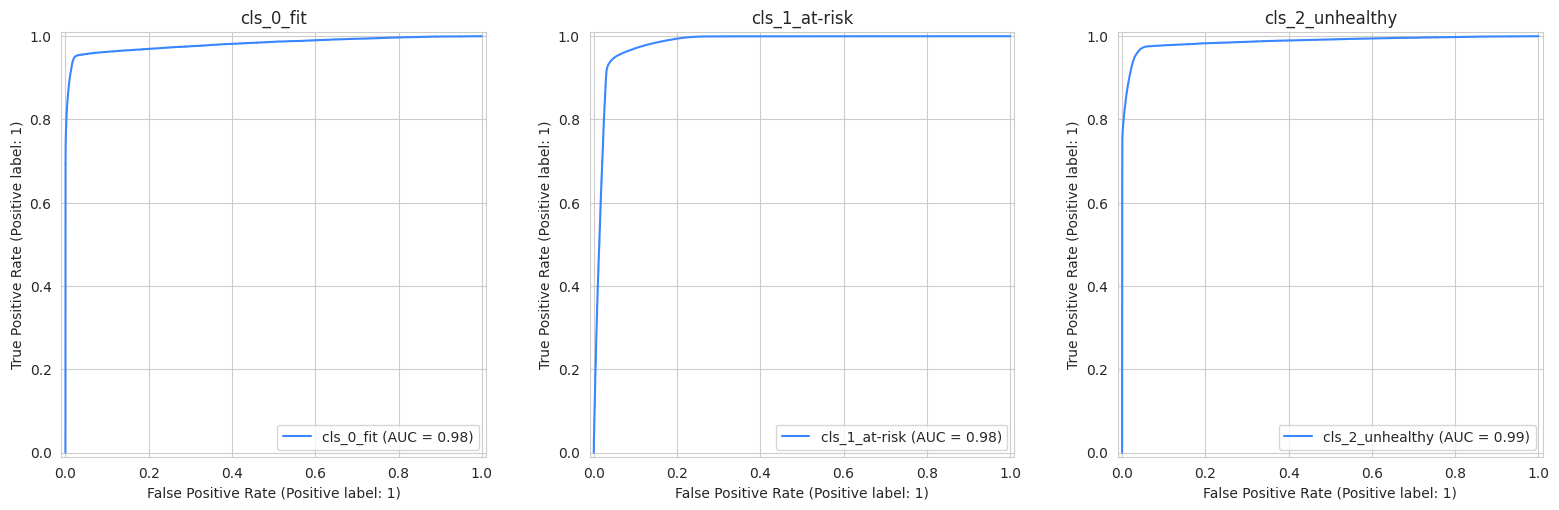


lgb_goss_200_94969 saved!


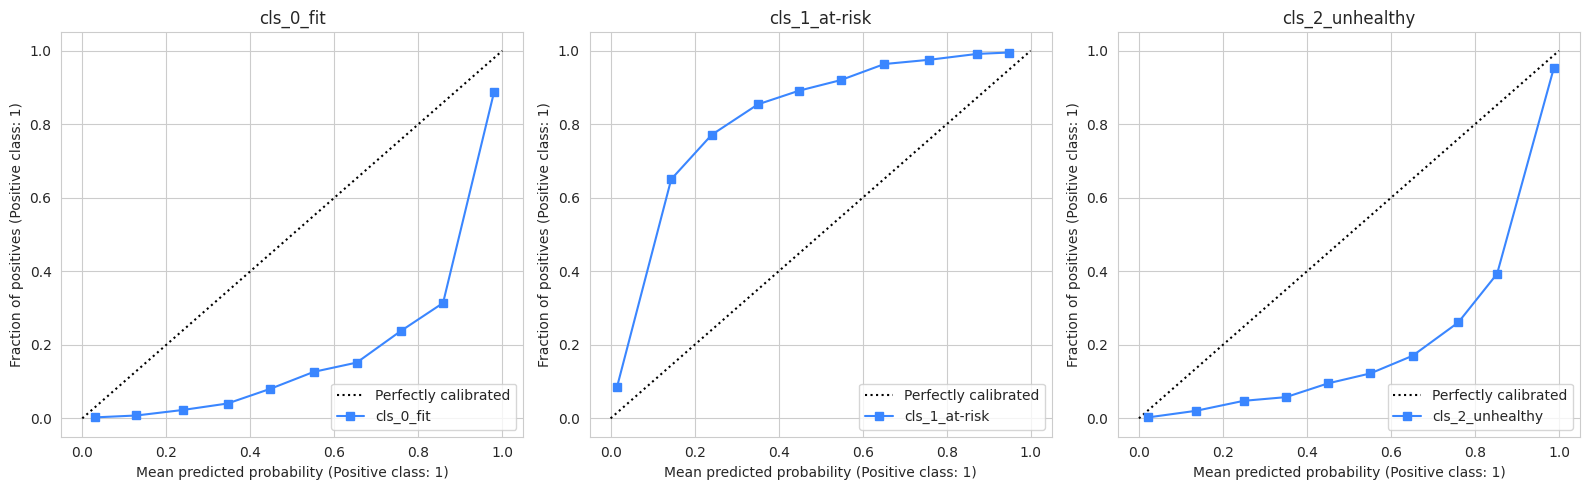

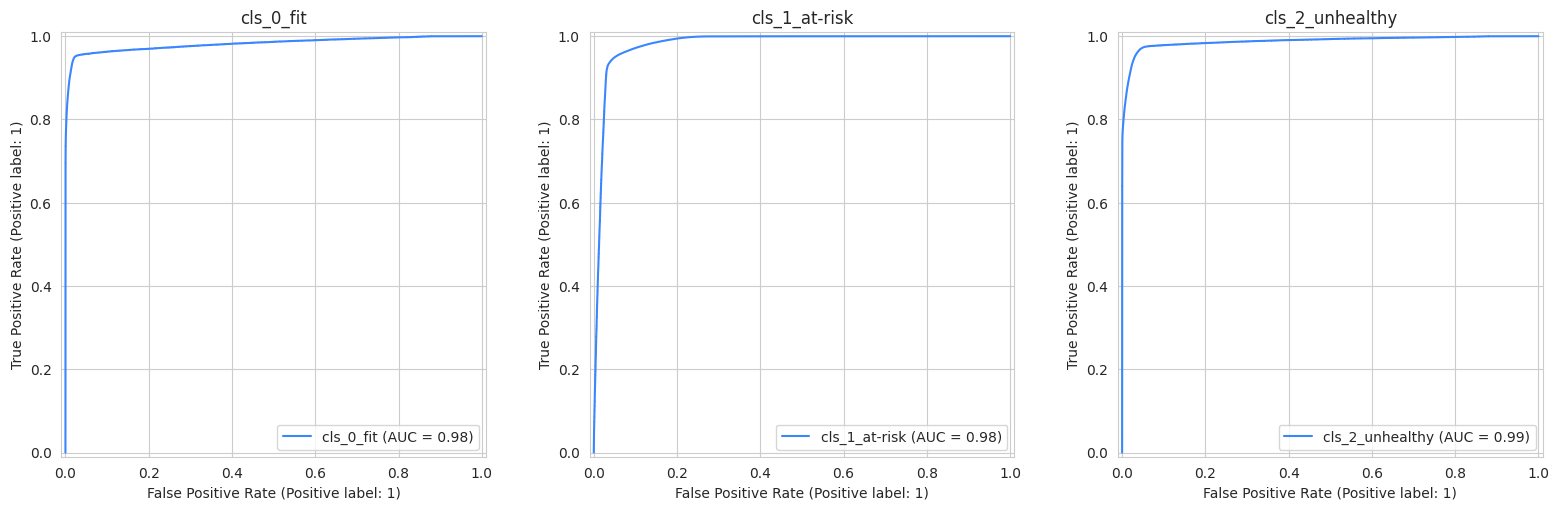


lgb_goss_300_94974 saved!


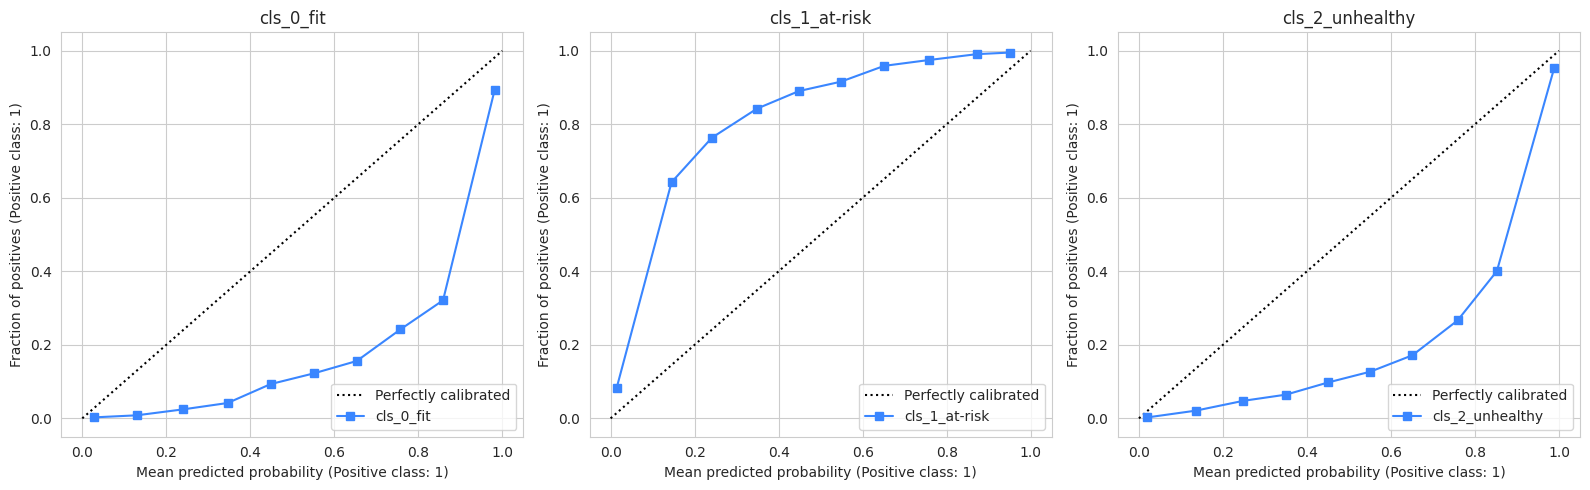

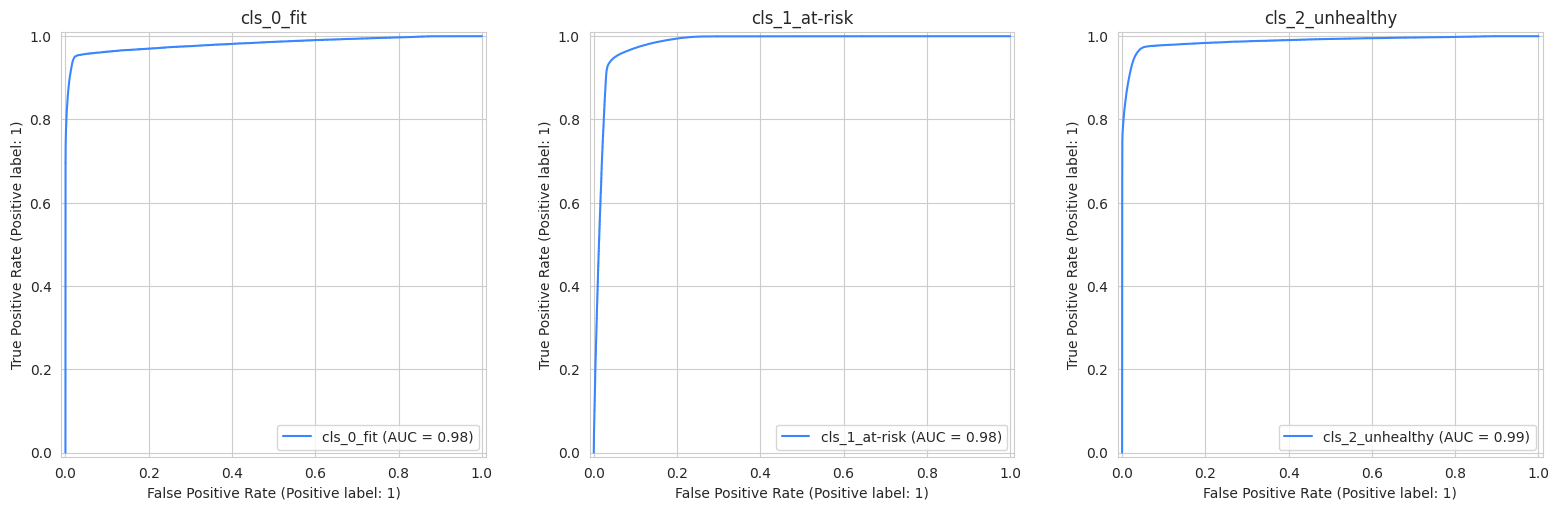

In [50]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            y_labels = pd.Series(np.argmax(y, axis=1))
            classes = [*mapping.keys()]
            name0 = f"cls_0_{classes[0]}"
            name1 = f"cls_1_{classes[1]}"
            name2 = f"cls_2_{classes[2]}"

            y_cls_0 = (train_data[TARGET] == 0).astype(int)
            y_cls_1 = (train_data[TARGET] == 1).astype(int)
            y_cls_2 = (train_data[TARGET] == 2).astype(int)
            p_cls_0 = y[:, 0]
            p_cls_1 = y[:, 1]
            p_cls_2 = y[:, 2]

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            CalibrationDisplay.from_predictions(y_cls_0, p_cls_0, n_bins=10, name=name0, ax=axs[0])
            CalibrationDisplay.from_predictions(y_cls_1, p_cls_1, n_bins=10, name=name1, ax=axs[1])
            CalibrationDisplay.from_predictions(y_cls_2, p_cls_2, n_bins=10, name=name2, ax=axs[2])
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            RocCurveDisplay.from_predictions(
                y_cls_0, p_cls_0, name=name0, ax=axs[0],
                sample_weight=get_sample_weights(y_cls_0, y_cls_0),
            )
            RocCurveDisplay.from_predictions(
                y_cls_1, p_cls_1, name=name1, ax=axs[1],
                sample_weight=get_sample_weights(y_cls_1, y_cls_1),
            )
            RocCurveDisplay.from_predictions(
                y_cls_2, p_cls_2, name=name2, ax=axs[2],
                sample_weight=get_sample_weights(y_cls_2, y_cls_2),
            )
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            print()

lgb_bag_94996 saved! (295753, 3)


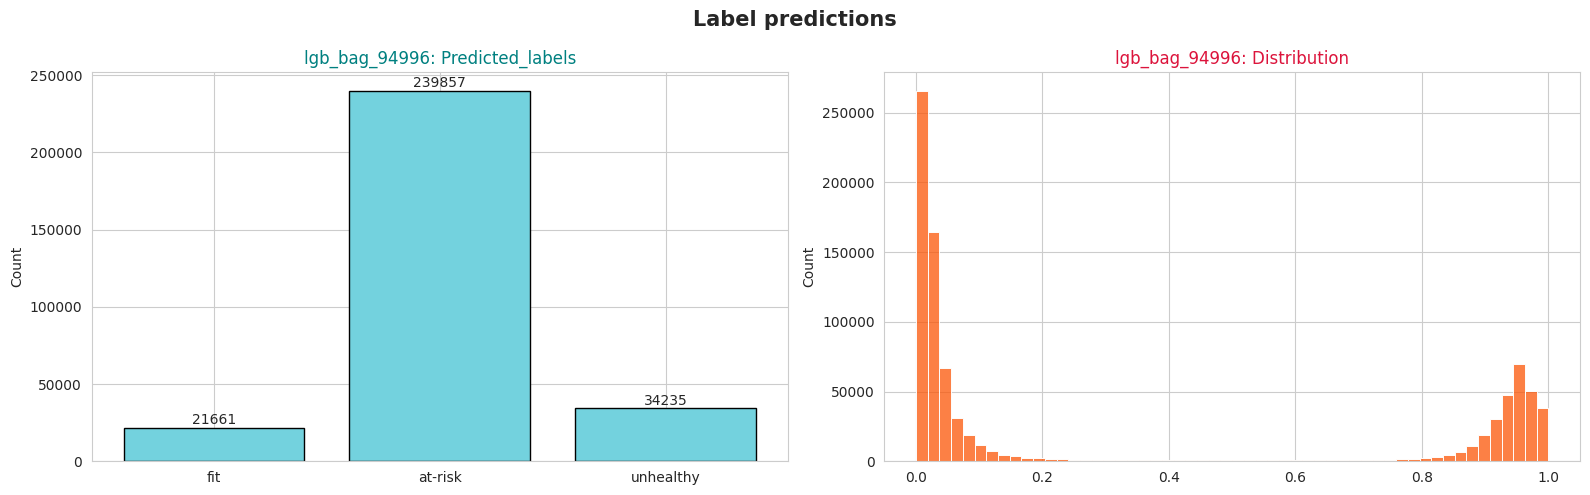


lgb_goss_100_94961 saved! (295753, 3)


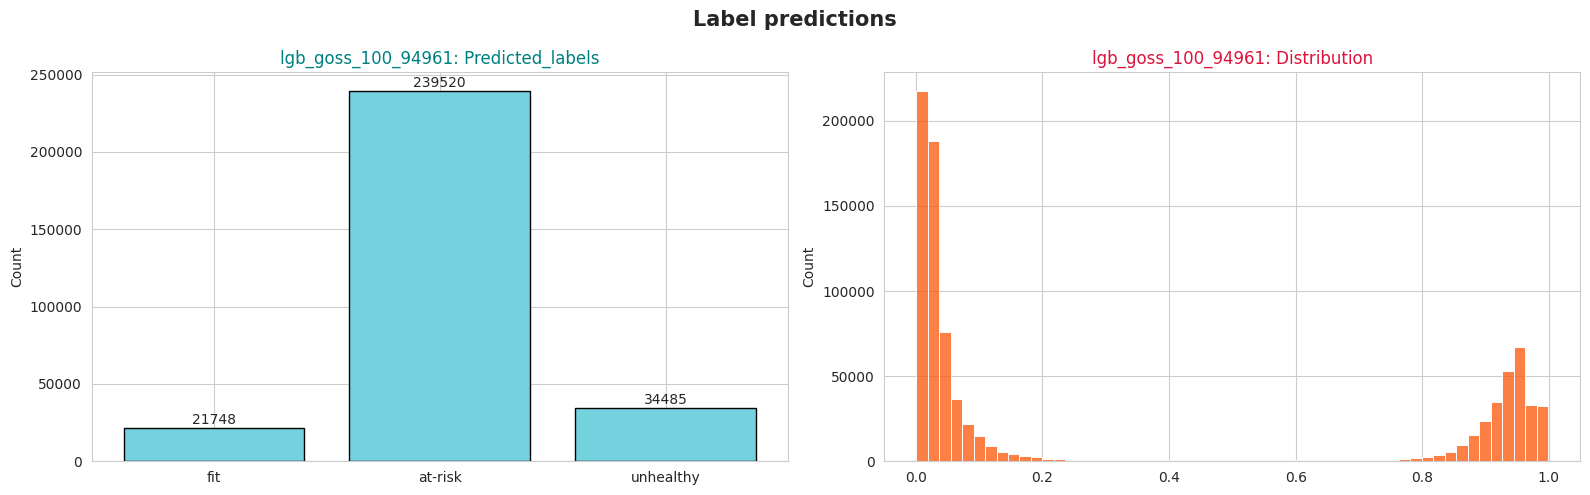


lgb_goss_200_94969 saved! (295753, 3)


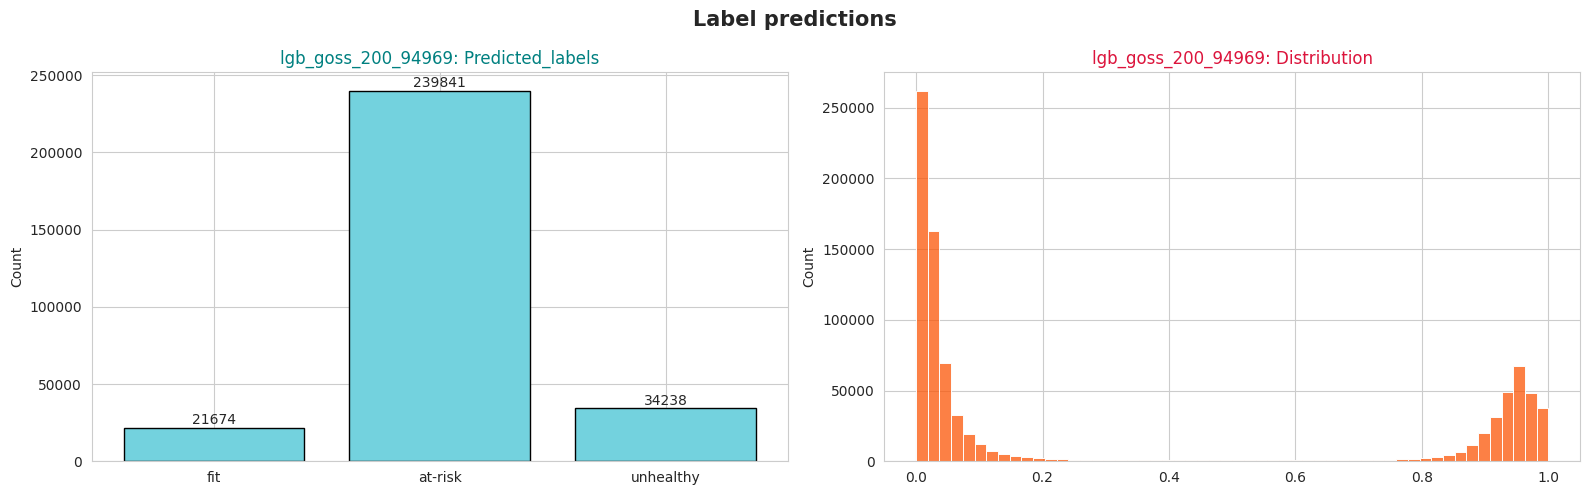


lgb_goss_300_94974 saved! (295753, 3)


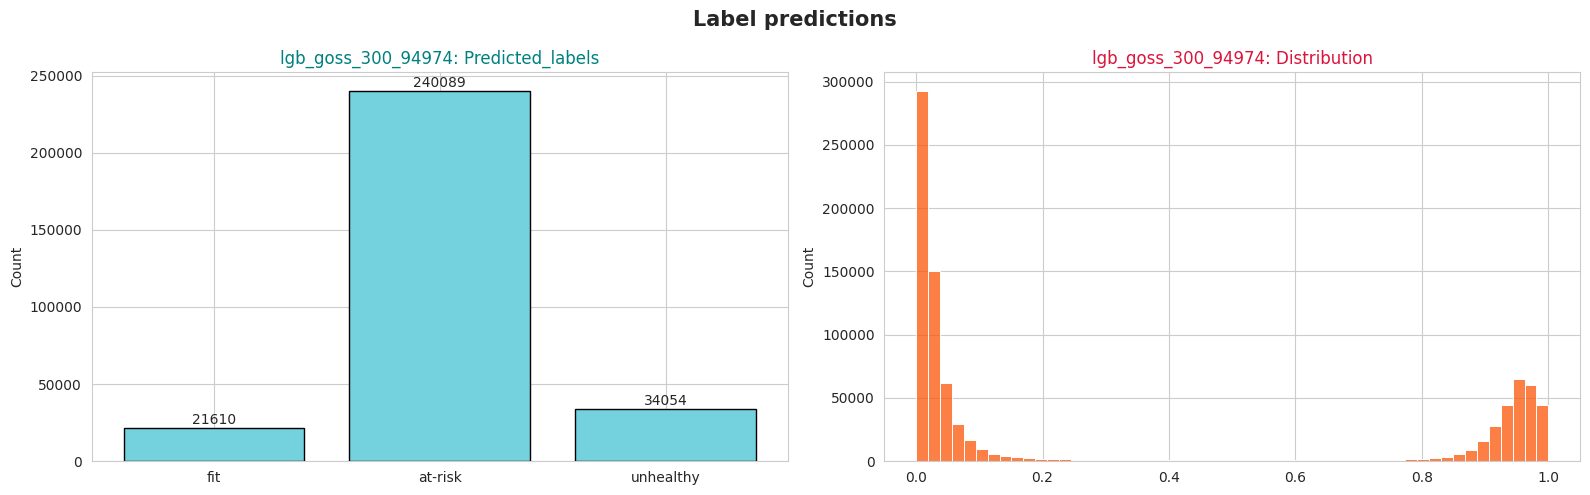

In [51]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"test_{n}_.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(16, 5))

            counts = [np.sum(y_labels == _) for _ in range(len(np.unique(y_labels)))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')

            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')

            plt.tight_layout()
            plt.show()

            print()

In [52]:
pd.DataFrame(model_results)

,lgb_bag_94996,lgb_goss_100_94961,lgb_goss_200_94969,lgb_goss_300_94974
0,unhealthy,unhealthy,unhealthy,unhealthy
1,unhealthy,unhealthy,unhealthy,unhealthy
2,at-risk,at-risk,at-risk,at-risk
3,at-risk,at-risk,at-risk,at-risk
4,unhealthy,unhealthy,unhealthy,unhealthy
...,...,...,...,...
295748,fit,fit,fit,fit
295749,at-risk,at-risk,at-risk,at-risk
295750,unhealthy,unhealthy,unhealthy,unhealthy
295751,at-risk,at-risk,at-risk,at-risk


In [53]:
# !rm -r /kaggle/working